# Part B — Classical Cox Proportional Hazards Modelling

This notebook renders Part B's figures from parquet files written by
`part_b_cox_model.py`. All plotting lives here; the compute script does
no plotting.

**Sections:**

- B(i) — Cox PH model on origination covariates (coefficient table, fit metrics)
- B(ii) — Hazard ratio plot
- B(iii) — Proportional hazards diagnostics (Schoenfeld test, residual scatter, log-log curves)
- B(iv) — Cox PH with vintage-macro covariates

**Important framing for B(iv).** The macro covariates (mortgage rate,
10yr Treasury, unemployment, HPI growth) are joined at each loan's
`FirstPaymentDate` — so they capture the macro environment at
**origination**, not dynamic refinancing incentive during the loan's
life. This is a vintage-macro Cox model, not a time-varying Cox model.
A proper time-varying treatment would need the full loan-month panel
(~hundreds of millions of rows for the full dataset), which exceeds the
memory budget for this assignment. See concern 8 in
`01_concerns_response.md`.


In [25]:
import sys
from pathlib import Path

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if NB_DIR.name == "results_b" else NB_DIR
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utilities import (
    RESULTS_B,
    LABEL_MAP,
    apply_plot_style,
)

apply_plot_style()


In [26]:
# Load every parquet file Part B produced
cox_base = pd.read_parquet(RESULTS_B / "cox_base_summary.parquet")
md_base = pd.read_parquet(RESULTS_B / "cox_base_metadata.parquet").iloc[0]
hr_base = pd.read_parquet(RESULTS_B / "hazard_ratios_base.parquet")
ph_test = pd.read_parquet(RESULTS_B / "ph_test.parquet")
schoenfeld = pd.read_parquet(RESULTS_B / "schoenfeld_residuals.parquet")
loglog = pd.read_parquet(RESULTS_B / "loglog_curves.parquet")
macro_panel = pd.read_parquet(RESULTS_B / "macro_panel.parquet")
cox_macro = pd.read_parquet(RESULTS_B / "cox_macro_summary.parquet")
md_macro = pd.read_parquet(RESULTS_B / "cox_macro_metadata.parquet").iloc[0]
hr_macro = pd.read_parquet(RESULTS_B / "hazard_ratios_macro.parquet")

print("Loaded:")
for name, df in [
    ("cox_base", cox_base), ("hr_base", hr_base), ("ph_test", ph_test),
    ("schoenfeld", schoenfeld), ("loglog", loglog),
    ("macro_panel", macro_panel),
    ("cox_macro", cox_macro), ("hr_macro", hr_macro),
]:
    print(f"  {name}: {len(df):>6,} rows")

print()
print("Base model metrics:", dict(md_base))
print("Macro model metrics:", dict(md_macro))


Loaded:
  cox_base:     15 rows
  hr_base:     15 rows
  ph_test:     15 rows
  schoenfeld: 1,633,125 rows
  loglog:  3,448 rows
  macro_panel:    328 rows
  cox_macro:     19 rows
  hr_macro:     19 rows

Base model metrics: {'label': 'base', 'n': np.int64(1582030), 'n_events': np.int64(1084858), 'n_covariates': np.int64(15), 'concordance': np.float64(0.6256827455105883), 'partial_AIC': np.float64(28769979.975015562), 'log_likelihood': np.float64(-14384974.987507781), 'penalizer': np.float64(0.001)}
Macro model metrics: {'label': 'macro', 'n': np.int64(1582030), 'n_events': np.int64(1084858), 'n_covariates': np.int64(19), 'concordance': np.float64(0.6428398571957111), 'partial_AIC': np.float64(28741469.656540208), 'log_likelihood': np.float64(-14370715.828270104), 'penalizer': np.float64(0.001)}


## B(i) — Cox PH on origination covariates

The base model has 15 origination-time covariates (FICO, LTV, original
interest rate, original UPB, DTI, plus categorical dummies). Output:


In [27]:
def fmt_summary(df):
    """Pretty-print the lifelines summary table."""
    keep = ["covariate", "coef", "exp(coef)",
            "exp(coef) lower 95%", "exp(coef) upper 95%",
            "se(coef)", "z", "p"]
    keep = [c for c in keep if c in df.columns]
    out = df[keep].copy()
    out["label"] = out["covariate"].map(lambda c: LABEL_MAP.get(c, c))
    out = out[["covariate", "label"] + [c for c in keep if c != "covariate"]]
    return out.sort_values("coef")

print(f"Base Cox model: n={int(md_base['n']):,}, "
      f"events={int(md_base['n_events']):,}")
print(f"  Concordance index: {md_base['concordance']:.4f}")
print(f"  Partial AIC:       {md_base['partial_AIC']:.1f}")
print(f"  Log-likelihood:    {md_base['log_likelihood']:.1f}")
print()
fmt_summary(cox_base).to_string(index=False)


Base Cox model: n=1,582,030, events=1,084,858
  Concordance index: 0.6257
  Partial AIC:       28769980.0
  Log-likelihood:    -14384975.0



'        covariate                       label      coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%  se(coef)          z             p\n    is_Investment         Investment Property -0.221582   0.801250             0.794692             0.807863  0.004193 -52.842337  0.000000e+00\n      DTI_missing                 DTI Missing -0.197702   0.820614             0.813960             0.827323  0.004154 -47.593833  0.000000e+00\n    is_SecondHome                 Second Home -0.145766   0.864360             0.856024             0.872776  0.004944 -29.483046 4.749243e-191\nis_FirstTimeBuyer            First-Time Buyer -0.058448   0.943227             0.937118             0.949376  0.003315 -17.629085  1.473325e-69\n   is_CashOutRefi               Cash-Out Refi -0.055586   0.945931             0.940852             0.951037  0.002747 -20.235910  4.728135e-91\n            LTV_z          LTV (standardized) -0.025369   0.974950             0.972657             0.977247  0.001201 -21.122978

In [28]:
fmt_summary(cox_base)


,covariate,label,coef,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,se(coef),z,p
8,is_Investment,Investment Property,-0.221582,0.801250,0.794692,0.807863,0.004193,-52.842337,0.000000e+00
5,DTI_missing,DTI Missing,-0.197702,0.820614,0.813960,0.827323,0.004154,-47.593833,0.000000e+00
9,is_SecondHome,Second Home,-0.145766,0.864360,0.856024,0.872776,0.004944,-29.483046,4.749243e-191
10,is_FirstTimeBuyer,First-Time Buyer,-0.058448,0.943227,0.937118,0.949376,0.003315,-17.629085,1.473325e-69
7,is_CashOutRefi,Cash-Out Refi,-0.055586,0.945931,0.940852,0.951037,0.002747,-20.235910,4.728135e-91
1,LTV_z,LTV (standardized),-0.025369,0.974950,0.972657,0.977247,0.001201,-21.122978,4.891244e-99
4,DTI_z,DTI (standardized),-0.007225,0.992801,0.990968,0.994636,0.000942,-7.666751,1.764071e-14
11,is_Condo,Condo,0.038680,1.039438,1.031903,1.047029,0.003712,10.419644,2.017059e-25
13,has_MI,Has Mortgage Insurance,0.039527,1.040319,1.034438,1.046232,0.002892,13.667400,1.589750e-42
6,is_Purchase,Purchase (vs Refi),0.064168,1.066272,1.060837,1.071735,0.002607,24.609213,1.006603e-133


## B(ii) — Hazard ratio plot

Each bar shows $e^{\beta_j}$ (the multiplicative effect of a one-unit
increase in covariate $j$ on the hazard) with 95% confidence interval.
Bars to the right of 1 (blue) → faster prepayment; to the left (red) →
slower prepayment.


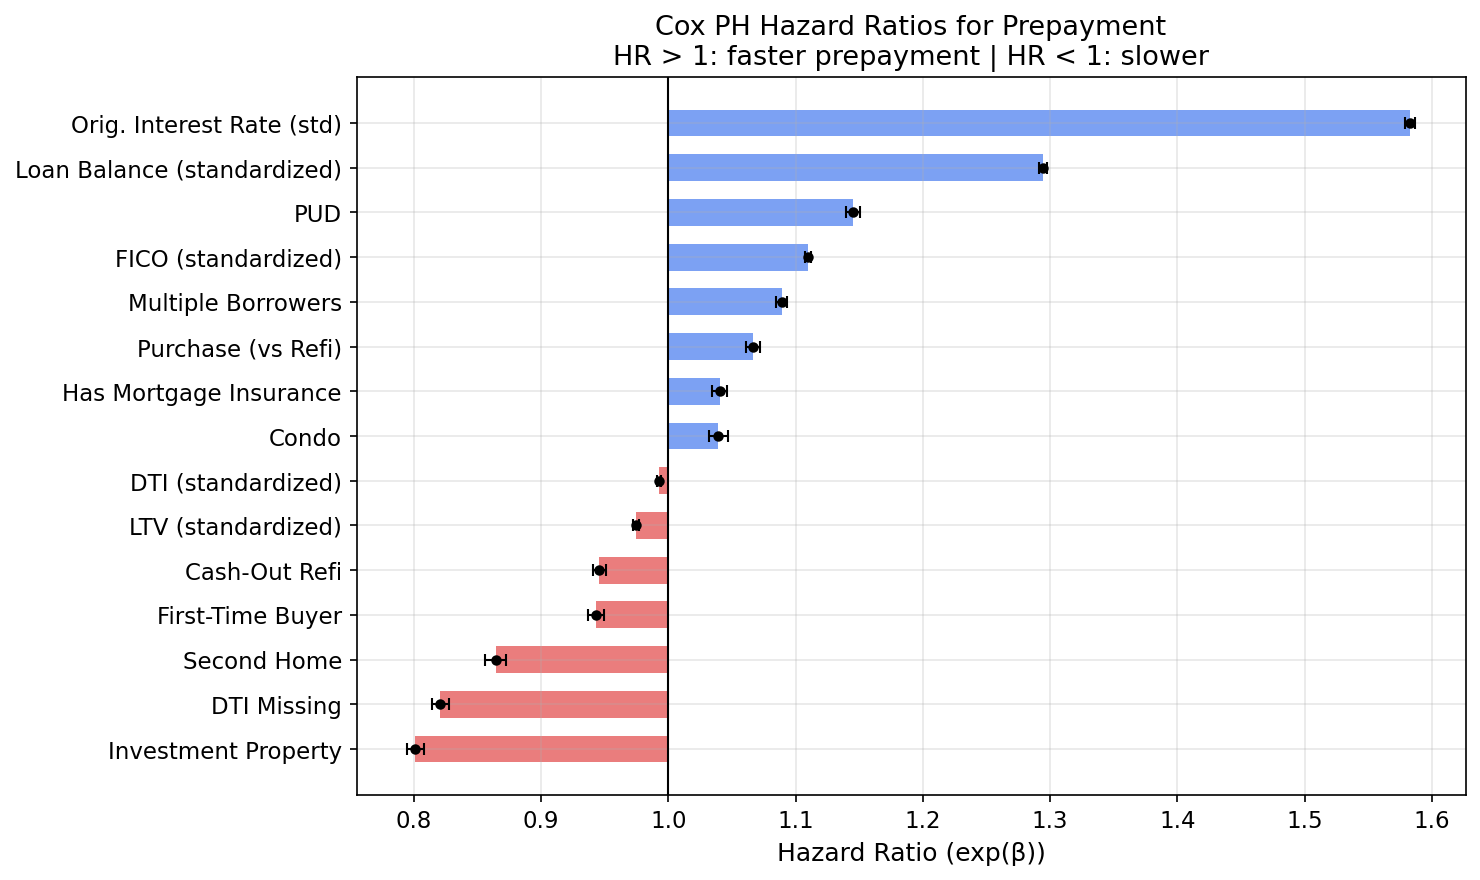

In [29]:
def plot_hazard_ratios(hr_df, title):
    """Forest plot of HR with 95% CI."""
    df = hr_df.sort_values("coef").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(df) * 0.4)))
    y = np.arange(len(df))
    hr = df["exp(coef)"].values
    ci_lo = df["exp(coef) lower 95%"].values
    ci_hi = df["exp(coef) upper 95%"].values
    colors = ["#2563EB" if h > 1 else "#DC2626" for h in hr]
    labels = df["label"].values

    ax.barh(y, hr - 1, left=1, color=colors, alpha=0.6, height=0.6)
    ax.errorbar(
        hr, y, xerr=[hr - ci_lo, ci_hi - hr],
        fmt="o", color="black", markersize=4, capsize=3, linewidth=1,
    )
    ax.axvline(1, color="black", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Hazard Ratio (exp(β))")
    ax.set_title(f"{title}\nHR > 1: faster prepayment | HR < 1: slower")
    fig.tight_layout()
    plt.show()

plot_hazard_ratios(hr_base, "Cox PH Hazard Ratios for Prepayment")


In [30]:
# Significance summary
def sig_marker(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

interp = hr_base.copy()
interp["sig"] = interp["p"].apply(sig_marker)
interp["direction"] = np.where(interp["exp(coef)"] > 1,
                                "↑ faster prepayment",
                                "↓ slower prepayment")
print(interp[["label", "exp(coef)", "p", "sig", "direction"]]
      .sort_values("exp(coef)", ascending=False)
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))


                      label  exp(coef)      p sig           direction
  Orig. Interest Rate (std)     1.5829 0.0000 *** ↑ faster prepayment
Loan Balance (standardized)     1.2943 0.0000 *** ↑ faster prepayment
                        PUD     1.1450 0.0000 *** ↑ faster prepayment
        FICO (standardized)     1.1098 0.0000 *** ↑ faster prepayment
         Multiple Borrowers     1.0892 0.0000 *** ↑ faster prepayment
         Purchase (vs Refi)     1.0663 0.0000 *** ↑ faster prepayment
     Has Mortgage Insurance     1.0403 0.0000 *** ↑ faster prepayment
                      Condo     1.0394 0.0000 *** ↑ faster prepayment
         DTI (standardized)     0.9928 0.0000 *** ↓ slower prepayment
         LTV (standardized)     0.9749 0.0000 *** ↓ slower prepayment
              Cash-Out Refi     0.9459 0.0000 *** ↓ slower prepayment
           First-Time Buyer     0.9432 0.0000 *** ↓ slower prepayment
                Second Home     0.8644 0.0000 *** ↓ slower prepayment
                DTI 

## B(iii) — Proportional hazards diagnostics

Three diagnostics for whether the PH assumption holds:

1. **Schoenfeld residual correlation test** — formal statistical test.
   For each covariate, $H_0$: hazard ratio is constant in time.
   Small $p$ ⇒ PH may be violated.
2. **Schoenfeld residual scatter** — visual: residuals should be
   mean-zero with no systematic trend in time.
3. **Log-log survival plot** — for stratified samples; parallel
   curves ⇒ PH holds across strata.


In [31]:
# 1. Formal test
if len(ph_test):
    ph_show = ph_test.copy()
    ph_show["sig"] = ph_show["p"].apply(sig_marker)
    ph_show = ph_show.sort_values("p")
    print("Schoenfeld correlation test (H0: PH holds for this covariate):")
    print(ph_show[["label", "p", "sig"]].to_string(index=False,
            float_format=lambda x: f"{x:.4f}"))
    print()
    n_violated = int((ph_show["p"] < 0.05).sum())
    print(f"  {n_violated}/{len(ph_show)} covariates show evidence of PH violation at α=0.05")
else:
    print("PH test output empty (sample too small or numerical issue).")


Schoenfeld correlation test (H0: PH holds for this covariate):
                      label      p sig
  Orig. Interest Rate (std) 0.0000 ***
                DTI Missing 0.0000 ***
Loan Balance (standardized) 0.0000 ***
         Purchase (vs Refi) 0.0000 ***
         LTV (standardized) 0.0000 ***
         Multiple Borrowers 0.0000 ***
           First-Time Buyer 0.0000 ***
        FICO (standardized) 0.0000 ***
        Investment Property 0.0000 ***
              Cash-Out Refi 0.0000 ***
                Second Home 0.0003 ***
         DTI (standardized) 0.0039  **
                        PUD 0.2705    
                      Condo 0.3765    
     Has Mortgage Insurance 0.6817    

  12/15 covariates show evidence of PH violation at α=0.05


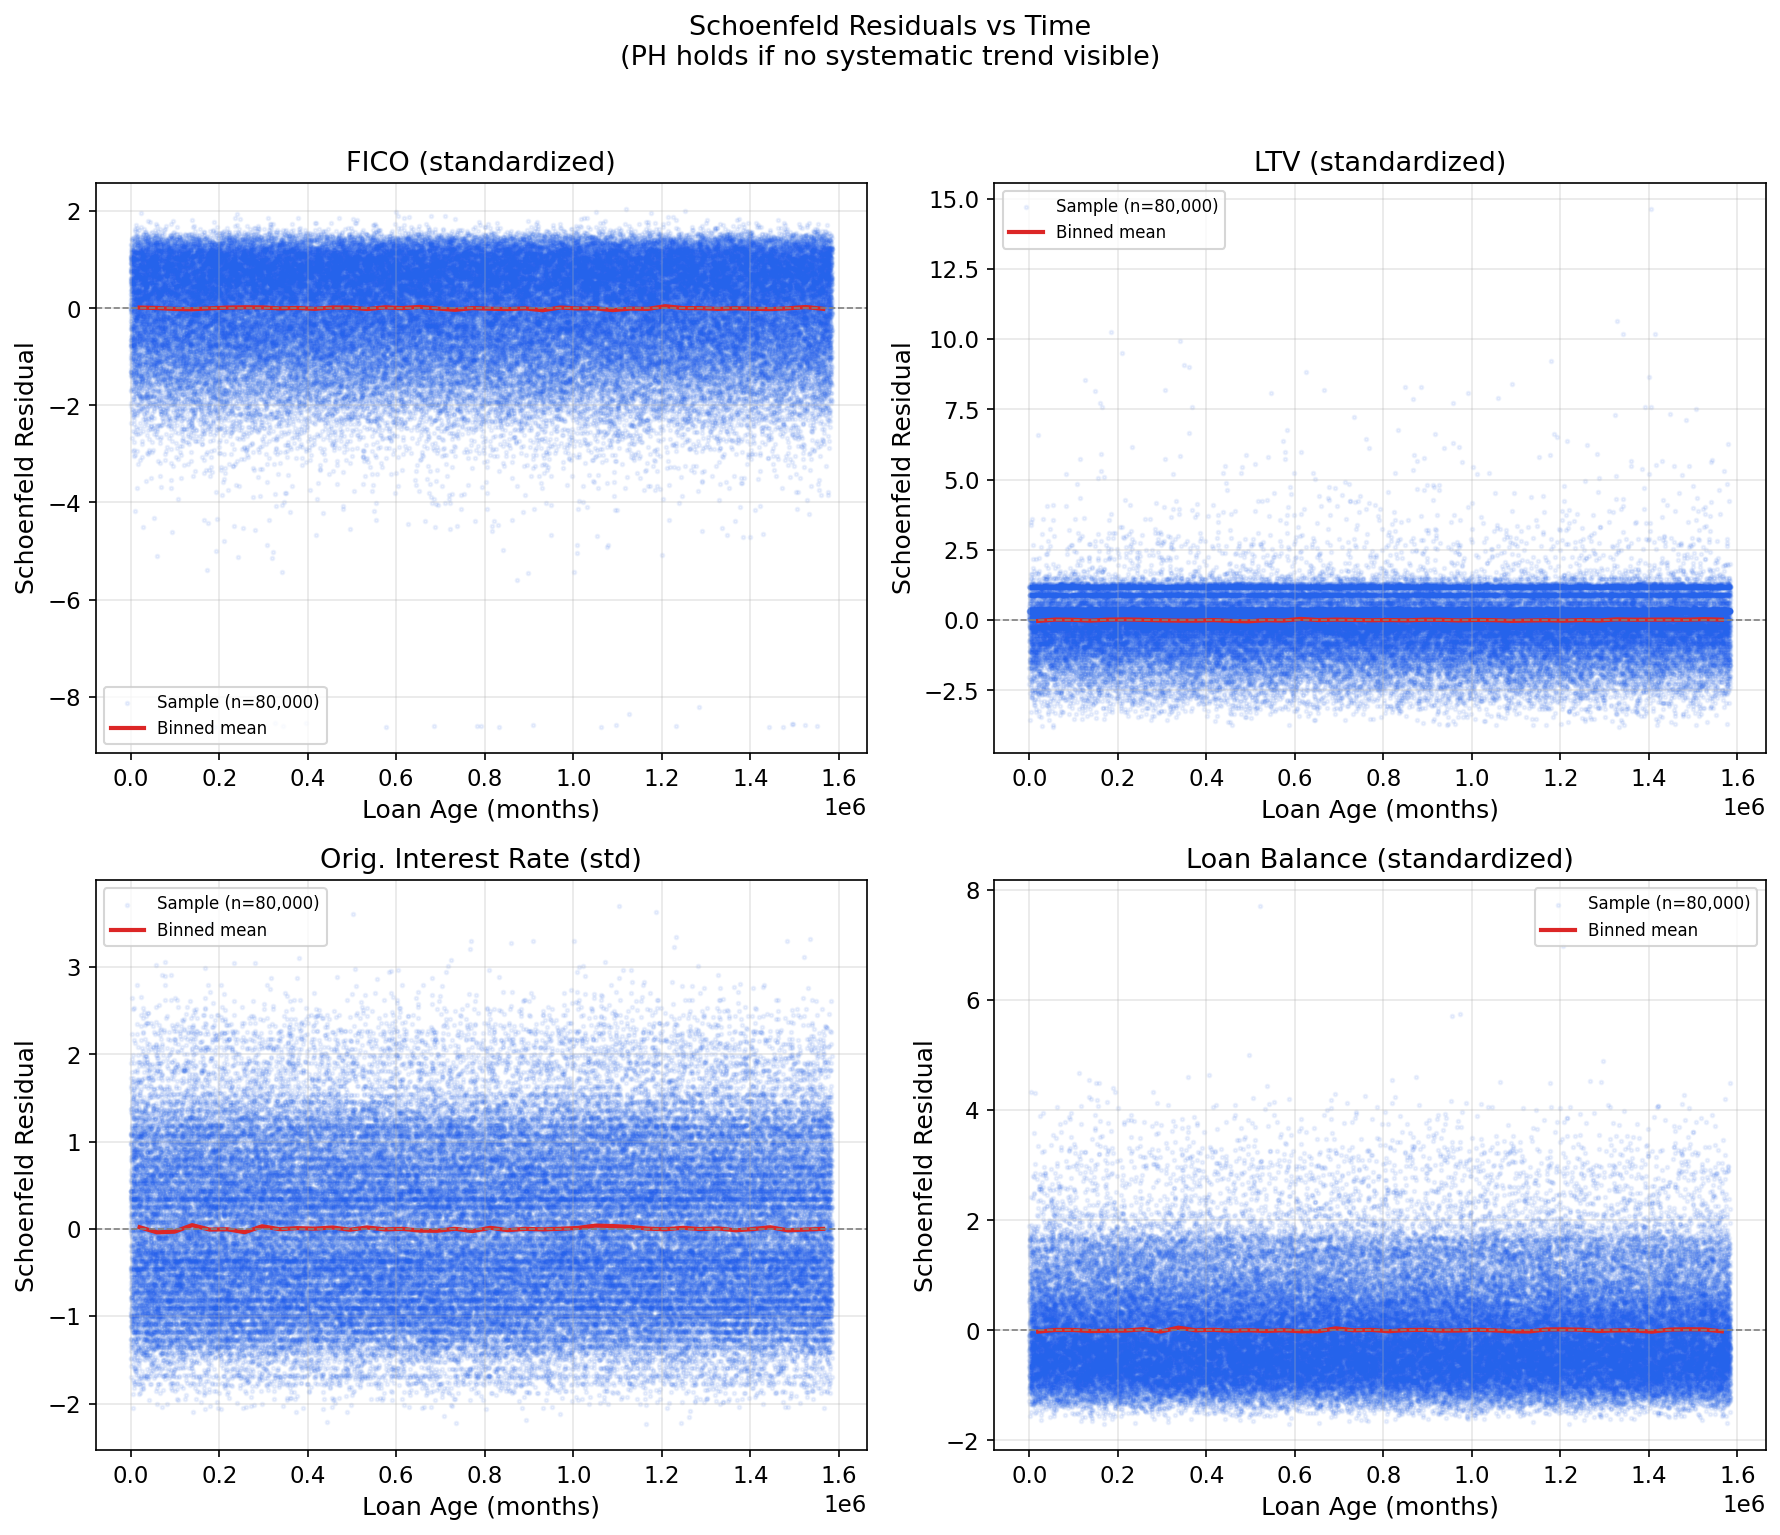

In [37]:
# 2. Schoenfeld residual scatter for the four most informative covariates
# The full residual table is large, so cap plotted points and use binned means
# instead of LOWESS. LOWESS on ~150k points per covariate is unnecessarily slow.
key_covs = ["FICO_z", "LTV_z", "Rate_z", "UPB_z"]
MAX_SCATTER_POINTS = 80_000
N_TREND_BINS = 40

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, cov in enumerate(key_covs):
    ax = axes[i]
    sub = schoenfeld[schoenfeld["covariate"] == cov]
    if len(sub) == 0:
        ax.text(0.5, 0.5, f"No residuals for {cov}",
                ha="center", va="center", transform=ax.transAxes)
        continue
    label = sub["label"].iloc[0]
    sub = sub[["Duration", "residual"]].dropna()

    if len(sub) > MAX_SCATTER_POINTS:
        scatter_sub = sub.sample(MAX_SCATTER_POINTS, random_state=42).sort_values("Duration")
    else:
        scatter_sub = sub.sort_values("Duration")

    ax.scatter(
        scatter_sub["Duration"], scatter_sub["residual"],
        alpha=0.08, s=3, color="#2563EB", rasterized=True,
        label=f"Sample (n={len(scatter_sub):,})",
    )

    bins = min(N_TREND_BINS, max(5, sub["Duration"].nunique()))
    trend = (
        sub.assign(time_bin=pd.cut(sub["Duration"], bins=bins, duplicates="drop"))
           .groupby("time_bin", observed=True)
           .agg(Duration=("Duration", "mean"), residual=("residual", "mean"))
           .dropna()
    )
    ax.plot(trend["Duration"], trend["residual"], color="#DC2626",
            linewidth=2, label="Binned mean")

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Loan Age (months)")
    ax.set_ylabel("Schoenfeld Residual")
    ax.set_title(label)
    ax.legend(fontsize=8)

fig.suptitle("Schoenfeld Residuals vs Time\n"
             "(PH holds if no systematic trend visible)",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


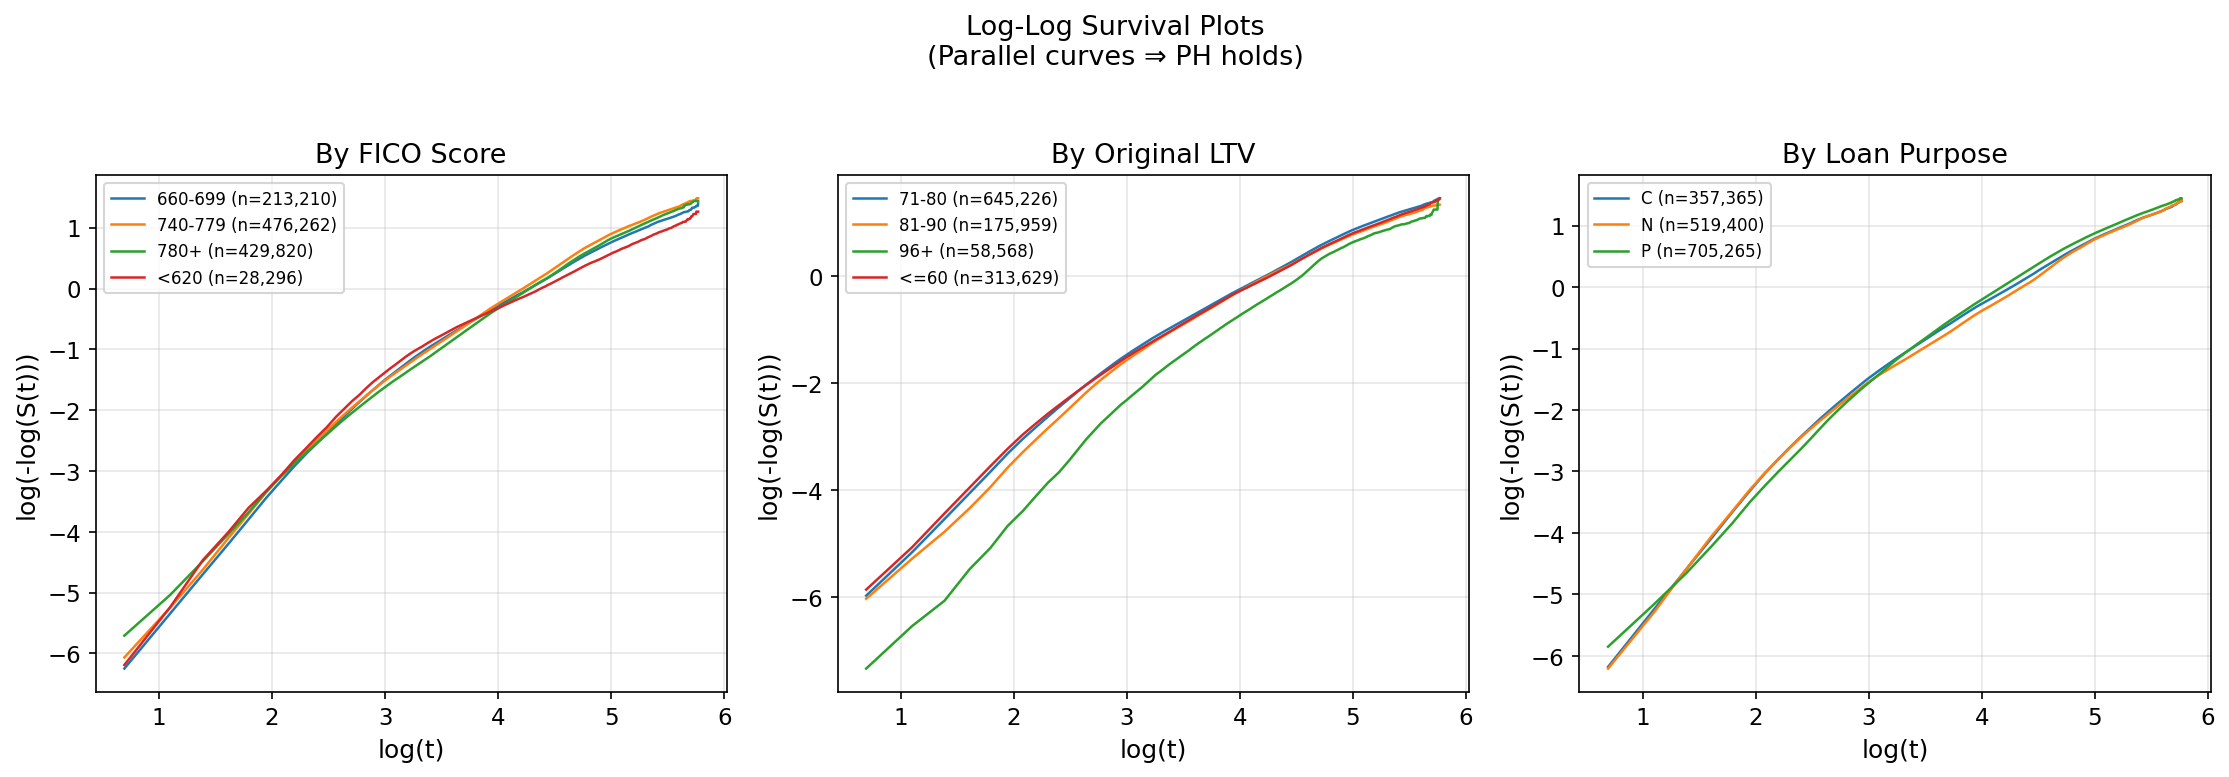

In [33]:
# 3. Log-log survival curves
if len(loglog):
    strat_vars = sorted(loglog["stratum_var"].unique())
    fig, axes = plt.subplots(1, len(strat_vars),
                              figsize=(5 * len(strat_vars), 5),
                              squeeze=False)
    axes = axes.ravel()

    for ax, var in zip(axes, strat_vars):
        sub = loglog[loglog["stratum_var"] == var]
        title = sub["stratum_label"].iloc[0]
        for stratum, group in sub.groupby("stratum"):
            n = int(group["n_in_stratum"].iloc[0])
            ax.plot(group["log_t"], group["log_log_S"],
                    linewidth=1.2, label=f"{stratum} (n={n:,})")
        ax.set_xlabel("log(t)")
        ax.set_ylabel("log(-log(S(t)))")
        ax.set_title(f"By {title}")
        ax.legend(fontsize=8)

    fig.suptitle("Log-Log Survival Plots\n(Parallel curves ⇒ PH holds)",
                 fontsize=13, y=1.03)
    fig.tight_layout()
    plt.show()
else:
    print("Log-log curves table is empty (no strata had enough events).")


## B(iv) — Cox PH with vintage-macro covariates

The macro panel below comes from FRED:

- **MORTGAGE30US** — 30-year fixed mortgage rate (weekly → monthly)
- **DGS10** — 10-year Treasury yield (daily → monthly)
- **UNRATE** — civilian unemployment rate (monthly)
- **CSUSHPINSA** — Case-Shiller national home price index (monthly)
- **FPCPITOTLZGUSA** — annual CPI inflation (annual → forward-filled)

We compute HPI year-over-year growth from CSUSHPINSA. All series are
joined onto each loan at its `FirstPaymentDate`.


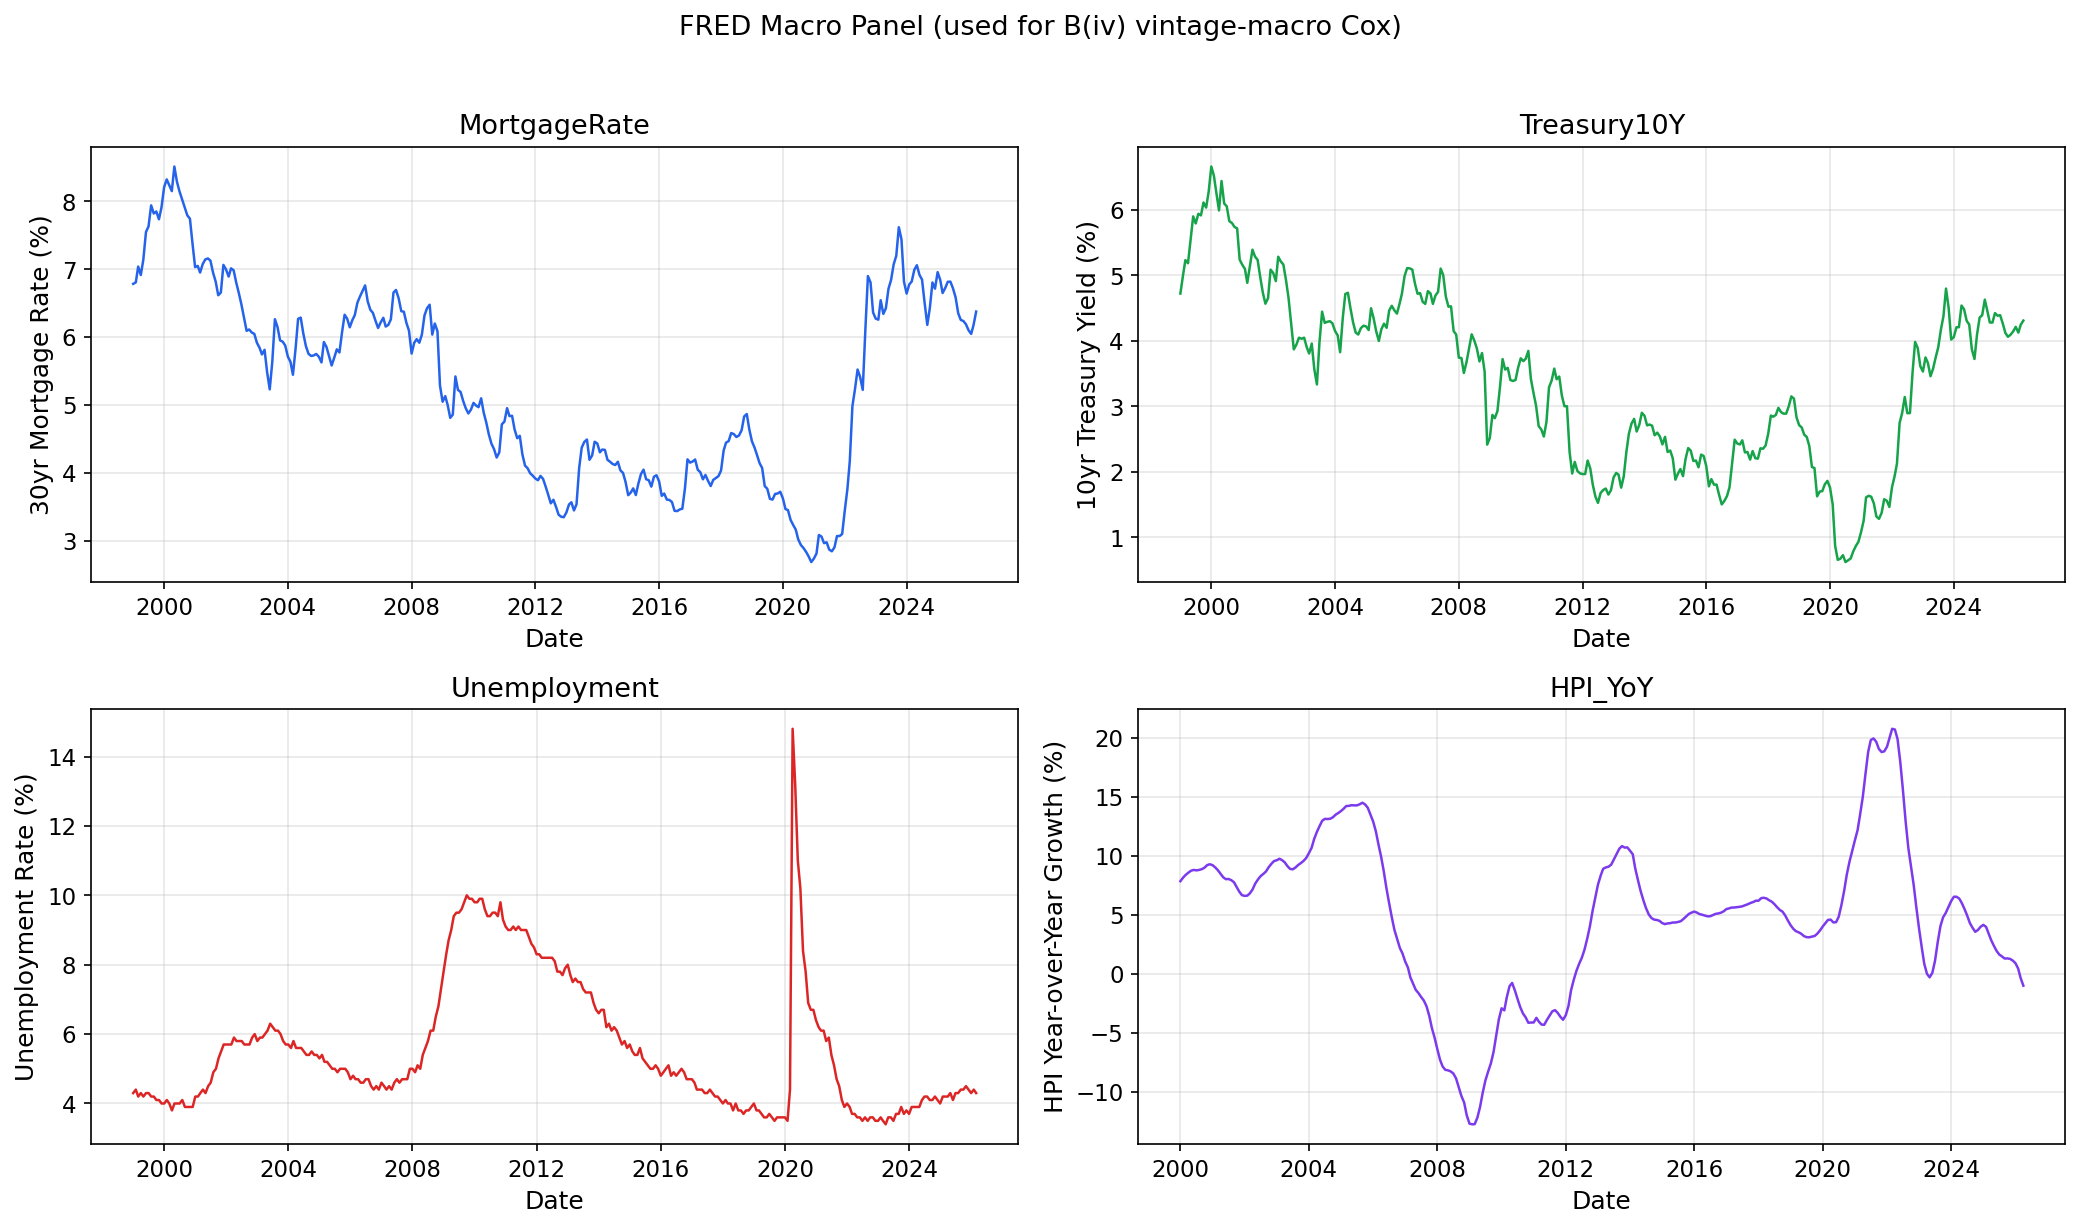

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

# Convert YYYYMM to a proper date for plotting
mp = macro_panel.copy()
mp["date"] = pd.to_datetime(
    mp["YYYYMM"].astype(str) + "01", format="%Y%m%d"
)

for ax, (col, color, ylabel) in zip(axes, [
    ("MortgageRate", "#2563EB", "30yr Mortgage Rate (%)"),
    ("Treasury10Y", "#16A34A", "10yr Treasury Yield (%)"),
    ("Unemployment", "#DC2626", "Unemployment Rate (%)"),
    ("HPI_YoY", "#7C3AED", "HPI Year-over-Year Growth (%)"),
]):
    if col in mp.columns:
        ax.plot(mp["date"], mp[col], color=color, linewidth=1.2)
        ax.set_title(col)
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Date")
        ax.grid(alpha=0.3)

fig.suptitle("FRED Macro Panel (used for B(iv) vintage-macro Cox)",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


In [35]:
print(f"Macro Cox model: n={int(md_macro['n']):,}, "
      f"events={int(md_macro['n_events']):,}, "
      f"covariates={int(md_macro['n_covariates'])}")
print(f"  Concordance index: {md_macro['concordance']:.4f}  "
      f"(base was {md_base['concordance']:.4f})")
print(f"  Partial AIC:       {md_macro['partial_AIC']:.1f}  "
      f"(base was {md_base['partial_AIC']:.1f})")
print()

# Highlight just the macro covariates
macro_covs = hr_macro[
    hr_macro["covariate"].str.endswith("_z")
    & ~hr_macro["covariate"].isin(
        ["FICO_z", "LTV_z", "Rate_z", "UPB_z", "DTI_z"])
].copy()
print("Macro covariate hazard ratios:")
print(macro_covs[["label", "coef", "exp(coef)", "p"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Macro Cox model: n=1,582,030, events=1,084,858, covariates=19
  Concordance index: 0.6428  (base was 0.6257)
  Partial AIC:       28741469.7  (base was 28769980.0)

Macro covariate hazard ratios:
                   label    coef  exp(coef)      p
10yr Treasury Rate (std) -0.2425     0.7846 0.0000
    HPI Growth YoY (std) -0.1179     0.8888 0.0000
 Unemployment Rate (std) -0.1127     0.8935 0.0000
30yr Mortgage Rate (std) -0.0567     0.9449 0.0000


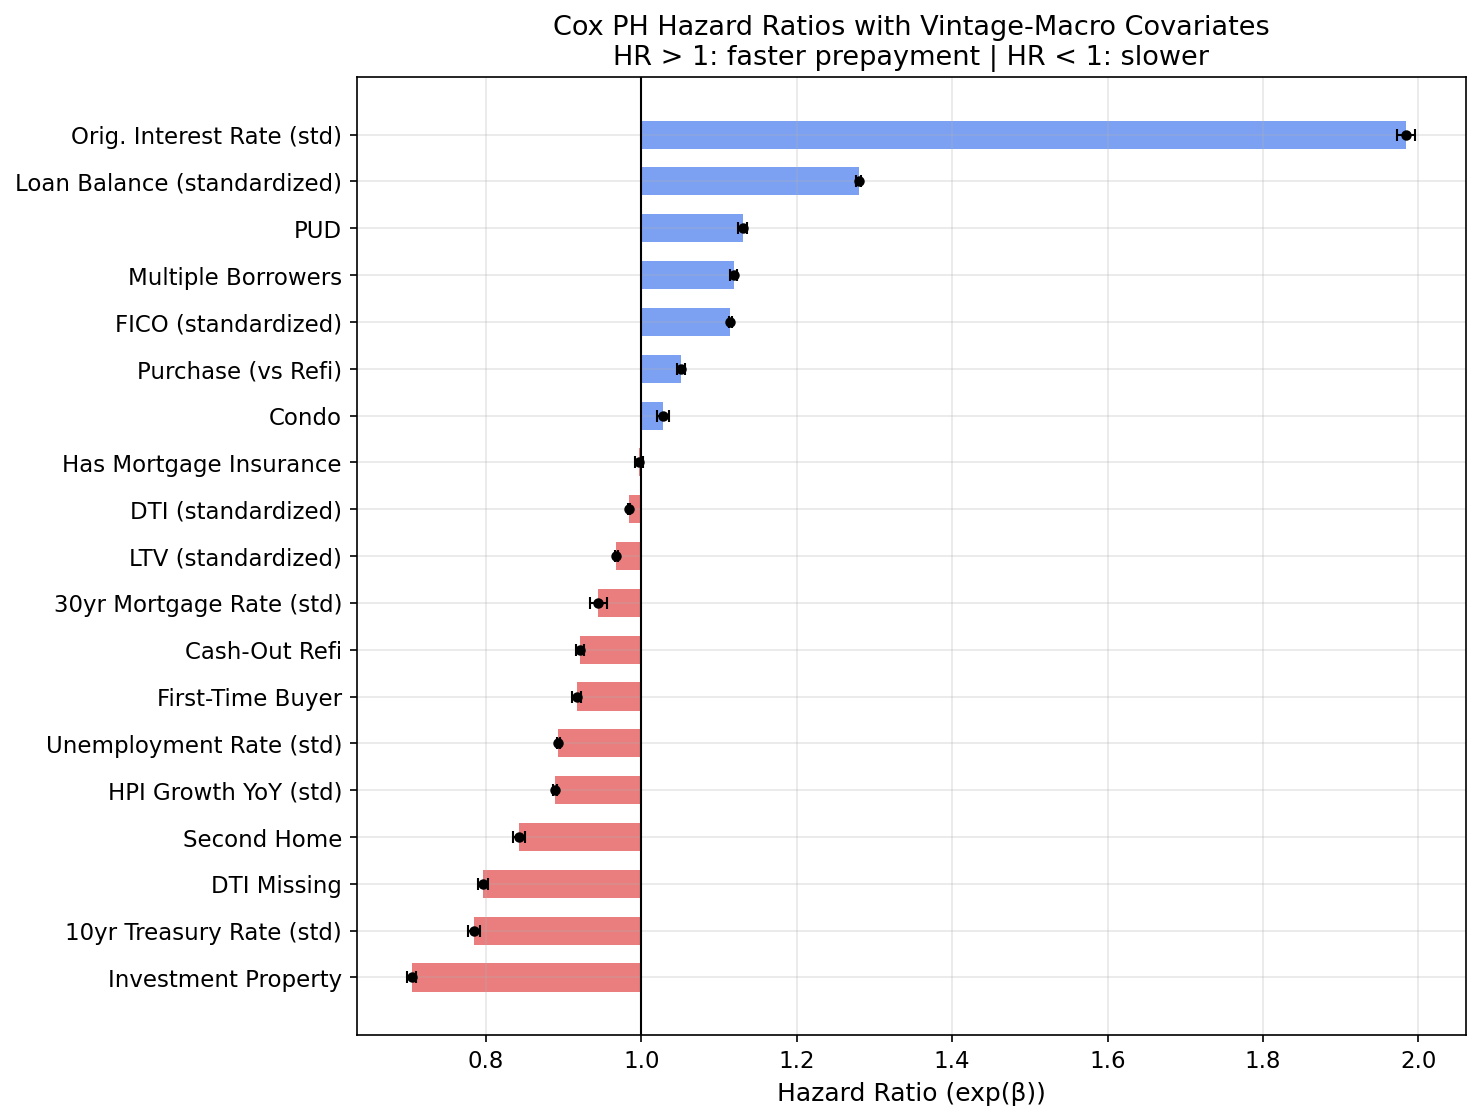

In [36]:
plot_hazard_ratios(hr_macro,
                    "Cox PH Hazard Ratios with Vintage-Macro Covariates")


## Limitations and caveats

- **B(iv) is a vintage-macro model, not time-varying.** Macro
  covariates are joined at the loan's `FirstPaymentDate`, so they
  describe the macro environment when each cohort was *originated*,
  not the dynamic refinancing incentive during each loan's life. The
  prepayment incentive (current rate − coupon) is the dominant driver
  of mortgage prepayment in real-world models, and we cannot capture
  it here without expanding to the full loan-month panel
  (memory-prohibitive at this scale). See concern 8.

- **PH assumption is approximate.** Several covariates show evidence
  of non-proportional hazards in the Schoenfeld test. The Cox model is
  still a useful baseline against which to compare ML / Deep Cox
  results in Parts C and D, but the literal coefficient interpretation
  ("a one-SD increase in FICO multiplies the hazard by exp(β) at
  *all* times $t$") should be taken with that caveat.

- **Non-informative censoring.** As in Part A, non-prepayment
  terminations (credit-related, whole-loan sale, etc.) are treated as
  non-informative censoring. Concern 10.
